# Streuungsmaße: Standardabweichung, Varianz und Spannweite

> Quelle: [numiqo.de](https://numiqo.de/tutorial/standardabweichung-varianz-spannweite)  
> Autor: Dr. Mathias Jesussek | Aktualisiert: 20.01.2026

**Streuungsmaße** (auch: Dispersionsmaße) beschreiben, wie stark die Werte einer Stichprobe um einen Lageparameter (z. B. den Mittelwert) schwanken.

> **Lagemaße** sagen uns, wo die Mitte der Daten liegt.  
> **Streuungsmaße** sagen uns, wie weit die Daten um diese Mitte streuen.

| Streuungsmaß | Beschreibung | Formel (kurz) |
|---|---|---|
| **Varianz** | Mittlere quadrierte Abweichung vom Mittelwert | $s^2 = \frac{\sum(x_i - \bar{x})^2}{n-1}$ |
| **Standardabweichung** | Wurzel der Varianz – in Originaleinheit | $s = \sqrt{s^2}$ |
| **Spannweite** | Abstand zwischen Minimum und Maximum | $R = x_{max} - x_{min}$ |
| **Interquartilsabstand** | Bereich der mittleren 50 % der Werte | $IQR = Q3 - Q1$ |

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Varianz

Die **Varianz** misst die durchschnittliche **quadrierte Abweichung** jedes Wertes vom Mittelwert.

### Formeln

**Populationsvarianz** (alle Werte der Grundgesamtheit bekannt):
$$\sigma^2 = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2$$

**Stichprobenvarianz** (Schätzung aus einer Stichprobe, Division durch $n-1$):
$$s^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2$$

> Die Division durch $n-1$ (statt $n$) korrigiert den **Bias** bei der Schätzung aus einer Stichprobe – dies nennt man **Bessel-Korrektur**.

### Eigenschaften
- Einheit ist **quadriert** (z. B. cm² bei Körpergröße in cm) → schwer interpretierbar
- Immer **≥ 0** (wegen Quadrierung)
- Je größer die Varianz, desto stärker streuen die Werte
- Grundlage für die Standardabweichung

In [17]:
# numiqo-Beispiel: Statistik-Prüfung
punkte = pd.Series([4, 5, 5, 8, 9, 12, 14, 16, 17, 20])
n   = len(punkte)
mw  = punkte.mean()

print(f"Daten:      {list(punkte)}")
print(f"n:          {n}")
print(f"Mittelwert: {mw}")

# Schritt-für-Schritt Varianzberechnung
abweichungen       = punkte - mw
abweichungen_quad  = abweichungen ** 2
summe_quad         = abweichungen_quad.sum()
varianz_stichprobe = summe_quad / (n - 1)

print("\nSchritt-für-Schritt: Varianz")
df_steps = pd.DataFrame({
    'xᵢ':           punkte.values,
    'xᵢ − x̄':      abweichungen.round(2).values,
    '(xᵢ − x̄)²':  abweichungen_quad.round(4).values
})
print(df_steps.to_string(index=False))
print(f"\nSumme (xᵢ−x̄)²: {summe_quad:.4f}")
print(f"Varianz s²  = {summe_quad:.4f} / (n-1={n-1}) = {varianz_stichprobe:.3f}")
print(f"\nKontrolle mit pandas .var(): {punkte.var():.3f}  ✓")

Daten:      [4, 5, 5, 8, 9, 12, 14, 16, 17, 20]
n:          10
Mittelwert: 11.0

Schritt-für-Schritt: Varianz
 xᵢ  xᵢ − x̄  (xᵢ − x̄)²
  4     -7.0        49.0
  5     -6.0        36.0
  5     -6.0        36.0
  8     -3.0         9.0
  9     -2.0         4.0
 12      1.0         1.0
 14      3.0         9.0
 16      5.0        25.0
 17      6.0        36.0
 20      9.0        81.0

Summe (xᵢ−x̄)²: 286.0000
Varianz s²  = 286.0000 / (n-1=9) = 31.778

Kontrolle mit pandas .var(): 31.778  ✓


## 2. Standardabweichung

Die **Standardabweichung** ist die **Quadratwurzel der Varianz** und gibt die Streuung in der **Originaleinheit** der Daten an – damit ist sie viel leichter zu interpretieren als die Varianz.

### Formeln

**Populationsstandardabweichung:**
$$\sigma = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2}$$

**Stichprobenstandardabweichung:**
$$s = \sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2} = \sqrt{s^2}$$

### Eigenschaften
- Gleiche Einheit wie die Ausgangsdaten (z. B. cm, €, Punkte)
- Gibt an: die Werte liegen im Durchschnitt **±s** um den Mittelwert
- Bei Normalverteilung:
  - ~68 % der Werte liegen im Bereich $[\bar{x} - s,\ \bar{x} + s]$
  - ~95 % der Werte liegen im Bereich $[\bar{x} - 2s,\ \bar{x} + 2s]$
  - ~99,7 % der Werte liegen im Bereich $[\bar{x} - 3s,\ \bar{x} + 3s]$

### Notation
| Symbol | Bedeutung |
|---|---|
| $s$ | Standardabweichung der **Stichprobe** |
| $\sigma$ (Sigma) | Standardabweichung der **Grundgesamtheit** |
| $s^2$ | Varianz der **Stichprobe** |
| $\sigma^2$ | Varianz der **Grundgesamtheit** |

Standardabweichung: Statistik-Prüfung
Varianz (s²):                   31.778
Standardabweichung s = √31.778: 5.637
Kontrolle: √31.778 = 5.637

Vergleich Stichprobe vs. Population:
  s  (ddof=1, Stichprobe):  5.637
  σ  (ddof=0, Population):  5.348


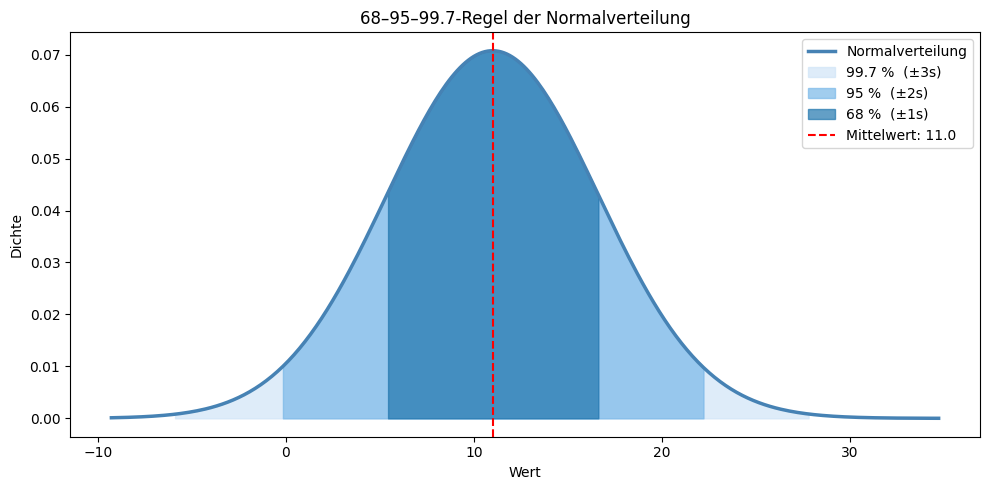

In [18]:
# Standardabweichung – Fortsetzung numiqo-Beispiel
varianz = punkte.var()          # Stichprobenvarianz (n-1)
std_s   = punkte.std()          # Stichproben-SD (n-1)
std_pop = punkte.std(ddof=0)    # Populations-SD (n)

print("Standardabweichung: Statistik-Prüfung")
print(f"Varianz (s²):                   {varianz:.3f}")
print(f"Standardabweichung s = √{varianz:.3f}: {std_s:.3f}")
print(f"Kontrolle: √{varianz:.3f} = {np.sqrt(varianz):.3f}")
print(f"\nVergleich Stichprobe vs. Population:")
print(f"  s  (ddof=1, Stichprobe):  {std_s:.3f}")
print(f"  σ  (ddof=0, Population):  {std_pop:.3f}")

# 68-95-99.7-Regel visualisieren
np.random.seed(42)
normaldata = np.random.normal(loc=punkte.mean(), scale=punkte.std(), size=500)
x = np.linspace(normaldata.min()-2, normaldata.max()+2, 300)
from scipy.stats import norm
y = norm.pdf(x, punkte.mean(), punkte.std())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y, color='steelblue', linewidth=2.5, label='Normalverteilung')
mu, s = punkte.mean(), punkte.std()

bereiche = [
    (mu-3*s, mu+3*s, '#d0e4f7', '99.7 %  (±3s)'),
    (mu-2*s, mu+2*s, '#7ab8e8', '95 %  (±2s)'),
    (mu-1*s, mu+1*s, '#2176ae', '68 %  (±1s)'),
]
for lo, hi, col, lbl in bereiche:
    mask = (x >= lo) & (x <= hi)
    ax.fill_between(x[mask], y[mask], alpha=0.7, color=col, label=lbl)

ax.axvline(mu, color='red', linestyle='--', linewidth=1.5, label=f'Mittelwert: {mu:.1f}')
ax.set_title('68–95–99.7-Regel der Normalverteilung')
ax.set_xlabel('Wert')
ax.set_ylabel('Dichte')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 3. Spannweite (Range)

Die **Spannweite** (auch: Range, Variationsbreite) ist das einfachste Streuungsmaß.  
Sie gibt den Abstand zwischen dem **Minimum** und dem **Maximum** einer Verteilung an.

### Formel
$$R = x_{max} - x_{min}$$

### Eigenschaften
- Sehr einfach zu berechnen und zu interpretieren
- Berücksichtigt **nur** die zwei extremsten Werte → sensitiv gegenüber Ausreißern
- Gibt keinen Aufschluss über die Verteilung der restlichen Werte
- Sinnvoll bei metrischen Variablen

### Beispiel (numiqo)
Körpergrößen von 7 Personen: kleinste = 1,50 m, größte = 1,90 m  
$$R = 1{,}90 - 1{,}50 = 0{,}40 \text{ m}$$

In [19]:
# Spannweite – numiqo-Beispiel Statistik-Prüfung
spannweite = punkte.max() - punkte.min()

print("Spannweite: Statistik-Prüfung")
print(f"Minimum:    {punkte.min()}")
print(f"Maximum:    {punkte.max()}")
print(f"Spannweite: {punkte.max()} - {punkte.min()} = {spannweite}")
print(f"\nKontrolle: punkte.max() - punkte.min() = {spannweite}")

# Körpergrössen-Beispiel
groessen = pd.Series([1.62, 1.72, 1.55, 1.70, 1.78, 1.65, 1.90])
print(f"\nKörpergrösse (Beispiel)")
print(f"Werte: {list(groessen)}")
print(f"Min: {groessen.min():.2f} m  |  Max: {groessen.max():.2f} m")
print(f"Spannweite: {groessen.max():.2f} - {groessen.min():.2f} = {groessen.max()-groessen.min():.2f} m")

Spannweite: Statistik-Prüfung
Minimum:    4
Maximum:    20
Spannweite: 20 - 4 = 16

Kontrolle: punkte.max() - punkte.min() = 16

Körpergrösse (Beispiel)
Werte: [1.62, 1.72, 1.55, 1.7, 1.78, 1.65, 1.9]
Min: 1.55 m  |  Max: 1.90 m
Spannweite: 1.90 - 1.55 = 0.35 m


## 4. Quartile und Interquartilsabstand (IQR)

**Quartile** teilen die sortierten Daten in vier gleich große Teile:

| Quartil | Bedeutung | Prozentsatz darunter |
|---|---|---|
| **Q1** (1. Quartil) | Median der unteren Hälfte | 25 % |
| **Q2** (2. Quartil) | Median der gesamten Daten | 50 % |
| **Q3** (3. Quartil) | Median der oberen Hälfte | 75 % |

### Interquartilsabstand (IQR)

$$IQR = Q3 - Q1$$

- Enthält die **mittleren 50 %** der Werte
- **Robust gegenüber Ausreißern** (ignoriert die extremen 25 % oben und unten)
- Grundlage für den **Boxplot**
- Ausreißer-Faustregel: Werte außerhalb von $[Q1 - 1{,}5 \cdot IQR,\ Q3 + 1{,}5 \cdot IQR]$

In [20]:
# Quartile und IQR
q1  = punkte.quantile(0.25)
q2  = punkte.quantile(0.50)   # = Median
q3  = punkte.quantile(0.75)
iqr = q3 - q1

print("=== Quartile: Statistik-Prüfung ===")
print(f"Sortierte Daten: {sorted(punkte.tolist())}")
print(f"\nQ1 (25. Perzentil): {q1}")
print(f"Q2 (Median / 50%):  {q2}")
print(f"Q3 (75. Perzentil): {q3}")
print(f"\nIQR = Q3 - Q1 = {q3} - {q1} = {iqr}")
print(f"Spannweite         = {punkte.max() - punkte.min()}")

# Ausreißer-Grenzen
untere_grenze = q1 - 1.5 * iqr
obere_grenze  = q3 + 1.5 * iqr
print(f"\nAusreißer-Grenzen (±1.5×IQR):")
print(f"  Untere Grenze: {untere_grenze:.2f}")
print(f"  Obere Grenze:  {obere_grenze:.2f}")
ausreisser = punkte[(punkte < untere_grenze) | (punkte > obere_grenze)]
print(f"  Ausreißer:     {list(ausreisser) if len(ausreisser) > 0 else 'keine'}") 

=== Quartile: Statistik-Prüfung ===
Sortierte Daten: [4, 5, 5, 8, 9, 12, 14, 16, 17, 20]

Q1 (25. Perzentil): 5.75
Q2 (Median / 50%):  10.5
Q3 (75. Perzentil): 15.5

IQR = Q3 - Q1 = 15.5 - 5.75 = 9.75
Spannweite         = 16

Ausreißer-Grenzen (±1.5×IQR):
  Untere Grenze: -8.88
  Obere Grenze:  30.12
  Ausreißer:     keine


## 5. Vollständiges Beispiel: Statistik-Prüfung (numiqo)

Alle Streuungsmaße auf einen Blick für den Datensatz aus numiqo:

| Studierende | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 |
|---|---|---|---|---|---|---|---|---|---|---|
| Punkte | 4 | 5 | 5 | 8 | 9 | 12 | 14 | 16 | 17 | 20 |

**Erwartete Ergebnisse laut numiqo:**

| Kennzahl | Wert |
|---|---|
| Standardabweichung | 5,637 |
| Varianz | 31,778 |
| Spannweite | 16 |

In [21]:
# Alle Streuungsmaße auf einen Blick
print("Vollständige deskriptive Statistik: Statistik-Prüfung")
print(f"\nDaten: {list(punkte)}")
print(f"n:                    {len(punkte)}")
print(f"\nLagemaße")
print(f"Mittelwert:           {punkte.mean():.3f}")
print(f"Median:               {punkte.median():.1f}")
print(f"Modus:                {punkte.mode()[0]}")
print(f"\nStreuungsmaße")
print(f"Varianz (s²):         {punkte.var():.3f}   ← numiqo: 31.778")
print(f"Standardabweichung:   {punkte.std():.3f}   ← numiqo: 5.637")
print(f"Spannweite:           {punkte.max()-punkte.min()}        ← numiqo: 16")
print(f"IQR:                  {punkte.quantile(0.75)-punkte.quantile(0.25):.2f}")
print(f"Min:                  {punkte.min()}")
print(f"Max:                  {punkte.max()}")
print(f"Q1:                   {punkte.quantile(0.25)}")
print(f"Q3:                   {punkte.quantile(0.75)}")

Vollständige deskriptive Statistik: Statistik-Prüfung

Daten: [4, 5, 5, 8, 9, 12, 14, 16, 17, 20]
n:                    10

Lagemaße
Mittelwert:           11.000
Median:               10.5
Modus:                5

Streuungsmaße
Varianz (s²):         31.778   ← numiqo: 31.778
Standardabweichung:   5.637   ← numiqo: 5.637
Spannweite:           16        ← numiqo: 16
IQR:                  9.75
Min:                  4
Max:                  20
Q1:                   5.75
Q3:                   15.5


## 6. Visualisierung der Streuungsmaße

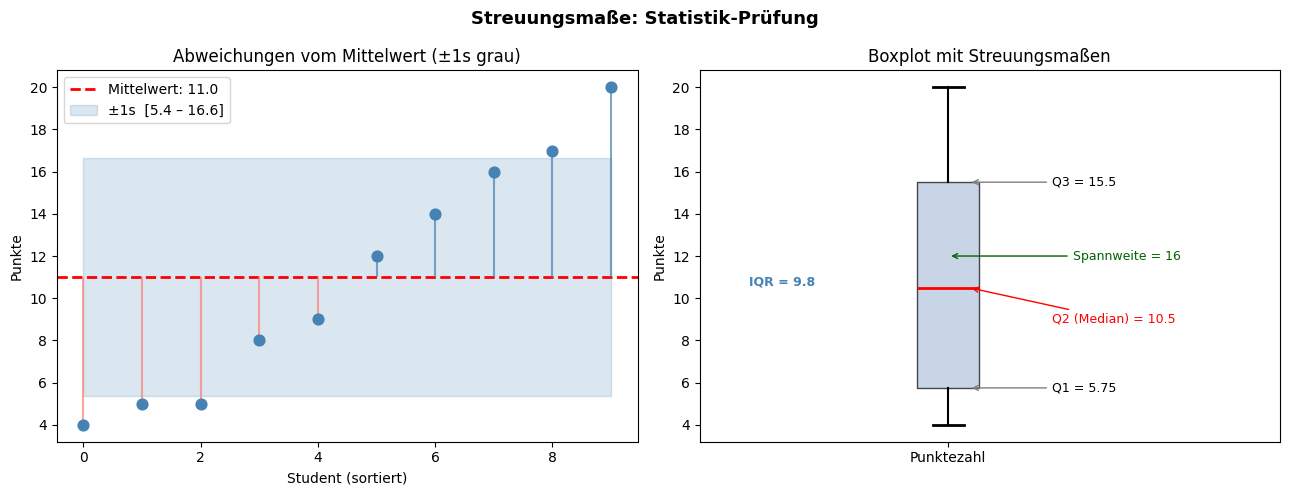

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Streuungsmaße: Statistik-Prüfung', fontsize=13, fontweight='bold')

# Links: Abweichungen vom Mittelwert
ax = axes[0]
mw = punkte.mean()
s  = punkte.std()
sortiert = punkte.sort_values().reset_index(drop=True)

ax.axhline(mw, color='red', linestyle='--', linewidth=2, label=f'Mittelwert: {mw:.1f}')
ax.fill_between(range(len(sortiert)),
                mw - s, mw + s, alpha=0.2, color='steelblue',
                label=f'±1s  [{mw-s:.1f} – {mw+s:.1f}]')
for i, val in enumerate(sortiert):
    farbe = 'steelblue' if val >= mw else 'salmon'
    ax.vlines(i, mw, val, colors=farbe, linewidth=1.5, alpha=0.7)
ax.scatter(range(len(sortiert)), sortiert, color='steelblue', zorder=5, s=60)
ax.set_title('Abweichungen vom Mittelwert (±1s grau)')
ax.set_xlabel('Student (sortiert)')
ax.set_ylabel('Punkte')
ax.legend()

# Rechts: Boxplot mit Annotierungen
ax2 = axes[1]
bp = ax2.boxplot(punkte, vert=True, patch_artist=True,
                 boxprops=dict(facecolor='lightsteelblue', alpha=0.7),
                 medianprops=dict(color='red', linewidth=2),
                 whiskerprops=dict(linewidth=1.5),
                 capprops=dict(linewidth=2))

q1_v = punkte.quantile(0.25)
q3_v = punkte.quantile(0.75)
med_v = punkte.median()
iqr_v = q3_v - q1_v
spw   = punkte.max() - punkte.min()

ax2.annotate(f'Q3 = {q3_v}', xy=(1.05, q3_v), xytext=(1.25, q3_v),
             fontsize=9, va='center',
             arrowprops=dict(arrowstyle='->', color='gray'))
ax2.annotate(f'Q2 (Median) = {med_v}', xy=(1.05, med_v), xytext=(1.25, med_v-1.5),
             fontsize=9, va='center', color='red',
             arrowprops=dict(arrowstyle='->', color='red'))
ax2.annotate(f'Q1 = {q1_v}', xy=(1.05, q1_v), xytext=(1.25, q1_v),
             fontsize=9, va='center',
             arrowprops=dict(arrowstyle='->', color='gray'))
ax2.annotate(f'IQR = {iqr_v:.1f}', xy=(0.6, (q1_v+q3_v)/2), fontsize=9,
             color='steelblue', fontweight='bold', ha='center')
ax2.annotate(f'Spannweite = {spw}', xy=(1.0, (punkte.min()+punkte.max())/2),
             xytext=(1.3, (punkte.min()+punkte.max())/2),
             fontsize=9, color='darkgreen', va='center',
             arrowprops=dict(arrowstyle='->', color='darkgreen'))

ax2.set_title('Boxplot mit Streuungsmaßen')
ax2.set_ylabel('Punkte')
ax2.set_xticklabels(['Punktezahl'])
ax2.set_xlim(0.4, 1.8)

plt.tight_layout()
plt.show()

## 7. Hohe vs. niedrige Streuung im Vergleich

Zwei Gruppen mit gleichem Mittelwert, aber unterschiedlicher Streuung:

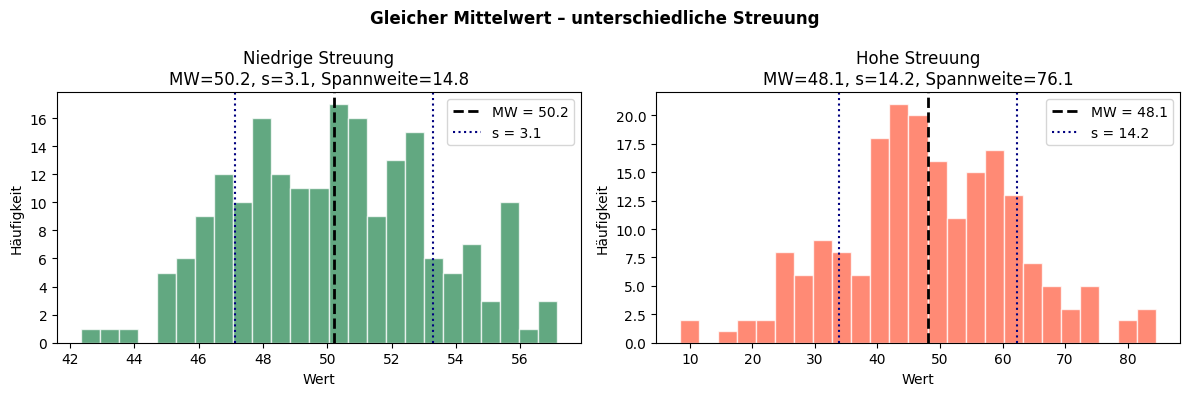

In [23]:
np.random.seed(0)
niedrig_streuung = np.random.normal(50, 3,  200)
hohe_streuung    = np.random.normal(50, 15, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
fig.suptitle('Gleicher Mittelwert – unterschiedliche Streuung', fontsize=12, fontweight='bold')

for ax, daten, titel, farbe in zip(
    axes,
    [niedrig_streuung, hohe_streuung],
    ['Niedrige Streuung', 'Hohe Streuung'],
    ['seagreen', 'tomato']
):
    mw_d = np.mean(daten)
    sd_d = np.std(daten, ddof=1)
    ax.hist(daten, bins=25, color=farbe, edgecolor='white', alpha=0.75)
    ax.axvline(mw_d, color='black', linestyle='--', linewidth=2,
               label=f'MW = {mw_d:.1f}')
    ax.axvline(mw_d - sd_d, color='navy', linestyle=':', linewidth=1.5,
               label=f's = {sd_d:.1f}')
    ax.axvline(mw_d + sd_d, color='navy', linestyle=':', linewidth=1.5)
    titel_str = f'{titel}\nMW={mw_d:.1f}, s={sd_d:.1f}, Spannweite={daten.max()-daten.min():.1f}'
    ax.set_title(titel_str)
    ax.set_xlabel('Wert')
    ax.set_ylabel('Häufigkeit')
    ax.legend()

plt.tight_layout()
plt.show()

## 8. Zusammenfassung

```
Streuungsmaße – Übersicht
│
├── VARIANZ (s²)
│   ├── Mittlere quadrierte Abweichung vom Mittelwert
│   ├── Einheit: quadriert (schwer interpretierbar)
│   ├── Stichprobe: s² = Σ(xᵢ−x̄)² / (n−1)
│   └── Population: σ² = Σ(xᵢ−μ)² / n
│
├── STANDARDABWEICHUNG (s / σ)
│   ├── Wurzel der Varianz – in Originaleinheit
│   ├── Stichprobe: s  (ddof=1)
│   ├── Population: σ  (ddof=0)
│   └── 68-95-99.7 Regel bei Normalverteilung
│
├── SPANNWEITE (R)
│   ├── R = Maximum − Minimum
│   ├── Einfach, aber sensitiv gegenüber Ausreißern
│   └── Nur zwei Werte werden berücksichtigt
│
└── INTERQUARTILSABSTAND (IQR)
    ├── IQR = Q3 − Q1
    ├── Enthält die mittleren 50 % der Werte
    └── Robust gegenüber Ausreißern (Basis des Boxplots)
```

| Maß | Robust ggü. Ausreißern | Einheit wie Daten | Alle Werte berücksichtigt |
|---|---|---|---|
| Varianz | ❌ | ❌ (quadriert) | ✅ |
| Standardabweichung | ❌ | ✅ | ✅ |
| Spannweite | ❌ | ✅ | ❌ (nur Min/Max) |
| IQR | ✅ | ✅ | ❌ (mittlere 50 %) |

---
Quelle: [numiqo.de/tutorial/standardabweichung-varianz-spannweite](https://numiqo.de/tutorial/standardabweichung-varianz-spannweite)